<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_NG1R_EXECUTED_Primitive_Non_Geometric_Parent_Medium_and_Constitutive_Response_Closure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ECSM NG1R — Primitive Non-Geometric Parent Medium and Constitutive Response Closure

This is the first technical notebook of the rebuilt non-geometric ECSM chain.

The physical variables are medium variables:

\[
\mathcal X=
\left(
n,\theta,\chi,q_{ij},z,X_A
\right),
\]

where:

- \(n\) is a response-density or amplitude variable;
- \(\theta\) is the compact coherent phase;
- \(\chi\in(0,1]\) is coherence;
- \(q_{ij}=q_{ji}\) is a **spatial constitutive response tensor**, not a spacetime metric;
- \(z\) is an internal-orientation field;
- \(X_A\) denotes finite bath or relaxation coordinates.

The primitive chain is

\[
\boxed{
\text{medium state}
\rightarrow
\text{constitutive stress}
\rightarrow
\text{propagation and relaxation}
\rightarrow
\text{observable response}.
}
\]

No physical spacetime metric, Ricci curvature, Einstein tensor, geodesic equation, Schwarzschild/Kerr geometry, or Einstein–Hilbert term is used.

The notebook establishes:

1. one conservative parent-medium action over ordinary spatial coordinates and an evolution parameter;
2. a positive constitutive free energy;
3. phase-density, compressional, tensorial, coherence, and internal-orientation modes;
4. a finite stable parameter region;
5. a bounded response to a localized source;
6. a machine-readable ontology audit and claim ledger.

It does **not** yet derive Newton's constant, PPN observables, lensing, gravitational-wave amplitudes, or compact-object predictions. Those belong to later rebuilt notebooks.


In [ ]:

from pathlib import Path
import json, math, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path('/mnt/data')
OUT = BASE/'ecsm_ng1r_outputs'
FIG = OUT/'paper_figures'
OUT.mkdir(exist_ok=True)
FIG.mkdir(exist_ok=True)

rng = np.random.default_rng(20260630)



## 1. Primitive action

Use an ordinary evolution parameter \(\lambda\) and Euclidean spatial coordinates \(x^i\).
The primitive action is

\[
S_{\rm med}
=
\int d\lambda\,d^3x\,
\left[
n\dot\theta
+\frac{A_q}{2}\dot q_{ij}\dot q_{ij}
+\frac{A_\chi}{2}\dot\chi^2
+A_z(\mathcal D_\lambda z)^\dagger(\mathcal D_\lambda z)
-\mathcal F
+\mathcal J
\right].
\]

The free-energy density is

\[
\begin{aligned}
\mathcal F={}&
\varepsilon(n,\chi)
+\frac{\kappa_n}{2}|\nabla n|^2
+\frac{\rho_s}{2}|\nabla\theta|^2
+\frac{\kappa_\chi}{2}|\nabla\chi|^2 \\
&+\frac{B_q}{2}\partial_kq_{ij}\partial_kq_{ij}
+\frac K2\left[\operatorname{tr}q-\alpha(n-n_0)\right]^2
+G\,q^{\rm dev}_{ij}q^{\rm dev}_{ij}\\
&+B_z(\mathcal D_i z)^\dagger(\mathcal D_i z)
+V_z(z,\chi).
\end{aligned}
\]

Here

\[
q^{\rm dev}_{ij}
=
q_{ij}
-\frac13\delta_{ij}\operatorname{tr}q,
\]

and the projected internal derivative is

\[
\mathcal D_i z
=
(I-zz^\dagger)\partial_i z.
\]

The Kronecker symbol \(\delta_{ij}\) is only the coordinate tensor of the ordinary spatial calculation.
It is not a spacetime metric or gravitational field.


In [ ]:

variables_df = pd.DataFrame([
    ('n', 'response density / amplitude', 'physical medium state', 'scalar'),
    ('theta', 'compact coherent phase', 'physical medium state', 'compact scalar'),
    ('chi', 'coherence fraction', 'physical medium state', 'bounded scalar'),
    ('q_ij', 'constitutive reconfiguration response', 'physical medium state', 'symmetric spatial tensor'),
    ('z', 'internal orientation', 'physical medium state', 'normalised complex doublet'),
    ('X_A', 'bath / relaxation coordinates', 'enlarged conservative system', 'internal coordinates'),
    ('delta_ij', 'spatial coordinate tensor', 'bookkeeping only', 'fixed Euclidean tensor'),
], columns=['symbol','meaning','status','type'])
variables_df.to_csv(OUT/'ng1r_primitive_variables.csv', index=False)
display(variables_df)


,symbol,meaning,status,type
0,n,response density / amplitude,physical medium state,scalar
1,theta,compact coherent phase,physical medium state,compact scalar
2,chi,coherence fraction,physical medium state,bounded scalar
3,q_ij,constitutive reconfiguration response,physical medium state,symmetric spatial tensor
4,z,internal orientation,physical medium state,normalised complex doublet
5,X_A,bath / relaxation coordinates,enlarged conservative system,internal coordinates
6,delta_ij,spatial coordinate tensor,bookkeeping only,fixed Euclidean tensor


In [ ]:

action_terms_df = pd.DataFrame([
    ('n theta_dot', 'canonical phase-density term', 'primitive'),
    ('A_q q_dot_ij q_dot_ij / 2', 'constitutive tensor storage', 'primitive'),
    ('A_chi chi_dot^2 / 2', 'coherence storage', 'primitive'),
    ('A_z |D_lambda z|^2', 'internal orientation storage', 'primitive'),
    ('epsilon(n,chi)', 'local equation of state', 'primitive'),
    ('kappa_n |grad n|^2 / 2', 'density-gradient stiffness', 'primitive'),
    ('rho_s |grad theta|^2 / 2', 'phase stiffness', 'primitive'),
    ('kappa_chi |grad chi|^2 / 2', 'coherence-gradient stiffness', 'primitive'),
    ('B_q |grad q_ij|^2 / 2', 'constitutive tensor-gradient stiffness', 'primitive'),
    ('K [tr(q)-alpha(n-n0)]^2 / 2', 'compression-density locking', 'primitive'),
    ('G q_dev:q_dev', 'shear / tensor response', 'primitive'),
    ('B_z |D_i z|^2 + V_z', 'orientation response', 'primitive'),
    ('J_n delta_n + J_ij q_ij + J_chi delta_chi', 'external loading probes', 'source only'),
], columns=['term','role','classification'])
action_terms_df.to_csv(OUT/'ng1r_action_terms.csv', index=False)
display(action_terms_df)


,term,role,classification
0,n theta_dot,canonical phase-density term,primitive
1,A_q q_dot_ij q_dot_ij / 2,constitutive tensor storage,primitive
2,A_chi chi_dot^2 / 2,coherence storage,primitive
3,A_z |D_lambda z|^2,internal orientation storage,primitive
4,"epsilon(n,chi)",local equation of state,primitive
5,kappa_n |grad n|^2 / 2,density-gradient stiffness,primitive
6,rho_s |grad theta|^2 / 2,phase stiffness,primitive
7,kappa_chi |grad chi|^2 / 2,coherence-gradient stiffness,primitive
8,B_q |grad q_ij|^2 / 2,constitutive tensor-gradient stiffness,primitive
9,K [tr(q)-alpha(n-n0)]^2 / 2,compression-density locking,primitive



## 2. Constitutive stress and equations of motion

The response stress conjugate to \(q_{ij}\) is

\[
\Sigma_{ij}
=
\frac{\partial\mathcal F}{\partial q_{ij}}
=
K\left[\operatorname{tr}q-\alpha(n-n_0)\right]\delta_{ij}
+
2Gq^{\rm dev}_{ij}.
\]

The parent equations are

\[
\dot n=\rho_s\nabla^2\theta,
\]

\[
\dot\theta
=
\varepsilon_{,n}
-\kappa_n\nabla^2n
-\alpha K\left[\operatorname{tr}q-\alpha(n-n_0)\right]
-J_n,
\]

\[
A_q\ddot q_{ij}
-
B_q\nabla^2q_{ij}
+
\Sigma_{ij}
=
J_{ij},
\]

\[
A_\chi\ddot\chi
-
\kappa_\chi\nabla^2\chi
+
\varepsilon_{,\chi}
+
V_{z,\chi}
=
J_\chi.
\]

The internal-orientation equation is the projected variational equation on the normalised orientation manifold.

These are constitutive medium equations. None is obtained by varying a spacetime metric.


In [ ]:

equations_df = pd.DataFrame([
    ('phase continuity', 'n_dot = rho_s Laplacian(theta)', 'derived from theta variation'),
    ('phase / chemical response', 'theta_dot = epsilon_n - kappa_n Laplacian(n) - alpha K[tr(q)-alpha delta_n] - J_n', 'derived from n variation'),
    ('constitutive tensor', 'A_q q_ddot - B_q Laplacian(q) + Sigma = J_q', 'derived from q variation'),
    ('coherence', 'A_chi chi_ddot - kappa_chi Laplacian(chi) + epsilon_chi + Vz_chi = J_chi', 'derived from chi variation'),
    ('constitutive stress', 'Sigma_ij = K[tr(q)-alpha delta_n] delta_ij + 2G qdev_ij', 'free-energy derivative'),
    ('orientation', 'projected Euler-Lagrange equation for z', 'normalisation-preserving variation'),
], columns=['sector','equation','origin'])
equations_df.to_csv(OUT/'ng1r_parent_equations.csv', index=False)
display(equations_df)


,sector,equation,origin
0,phase continuity,n_dot = rho_s Laplacian(theta),derived from theta variation
1,phase / chemical response,theta_dot = epsilon_n - kappa_n Laplacian(n) -...,derived from n variation
2,constitutive tensor,A_q q_ddot - B_q Laplacian(q) + Sigma = J_q,derived from q variation
3,coherence,A_chi chi_ddot - kappa_chi Laplacian(chi) + ep...,derived from chi variation
4,constitutive stress,Sigma_ij = K[tr(q)-alpha delta_n] delta_ij + 2...,free-energy derivative
5,orientation,projected Euler-Lagrange equation for z,normalisation-preserving variation



## 3. Local convexity

Choose the local equation of state near the coherent reference state:

\[
\varepsilon(n,\chi)
=
\frac a2\delta n^2
+\frac b4\delta n^4
+\frac{m_\chi^2}{2}\delta\chi^2
+\frac{\lambda_\chi}{4}\delta\chi^4
+\frac{g_{n\chi}}2\delta n^2\delta\chi^2,
\]

where

\[
\delta n=n-n_0,
\qquad
\delta\chi=\chi-1.
\]

In the scalar compression sector \(Q=\operatorname{tr}q\),

\[
\mathcal F_{\rm scalar}^{(2)}
=
\frac12(a+K\alpha^2)\delta n^2
-K\alpha\,\delta nQ
+\frac K2Q^2.
\]

Its Hessian is

\[
H_{\rm scalar}
=
\begin{pmatrix}
a+K\alpha^2 & -K\alpha\\
-K\alpha & K
\end{pmatrix},
\]

with

\[
\det H_{\rm scalar}=aK.
\]

Therefore \(a>0\) and \(K>0\) are sufficient for strict local convexity, independently of the locking strength \(\alpha\).


In [ ]:

params = {
    'n0':1.0,
    'chi0':1.0,
    'a':1.0,
    'b':0.8,
    'm_chi_sq':0.9,
    'lambda_chi':0.7,
    'g_nchi':0.25,
    'K':1.5,
    'G':0.7,
    'alpha':0.3,
    'kappa_n':0.15,
    'rho_s':0.65,
    'A_q':1.0,
    'B_q':0.45,
    'A_chi':0.9,
    'kappa_chi':0.5,
    'A_z':0.8,
    'B_z':0.7,
    'Omega_z_sq':1.1,
    'c_reference':1.0,
}
params_df = pd.DataFrame(list(params.items()), columns=['parameter','value'])
params_df.to_csv(OUT/'ng1r_benchmark_parameters.csv', index=False)
display(params_df)

a = params['a']
K = params['K']
alpha = params['alpha']
H = np.array([[a+K*alpha**2, -K*alpha],[-K*alpha,K]])
evals = np.linalg.eigvalsh(H)
convexity_df = pd.DataFrame({
    'quantity':['H_eigenvalue_min','H_eigenvalue_max','H_determinant','analytic_aK'],
    'value':[evals.min(),evals.max(),np.linalg.det(H),a*K]
})
convexity_df.to_csv(OUT/'ng1r_convexity_summary.csv', index=False)
display(convexity_df)

assert np.all(evals>0)
assert np.isclose(np.linalg.det(H),a*K)


,parameter,value
0,n0,1.00
1,chi0,1.00
2,a,1.00
3,b,0.80
4,m_chi_sq,0.90
5,lambda_chi,0.70
6,g_nchi,0.25
7,K,1.50
8,G,0.70
9,alpha,0.30


,quantity,value
0,H_eigenvalue_min,0.831901
1,H_eigenvalue_max,1.803099
2,H_determinant,1.500000
3,analytic_aK,1.500000


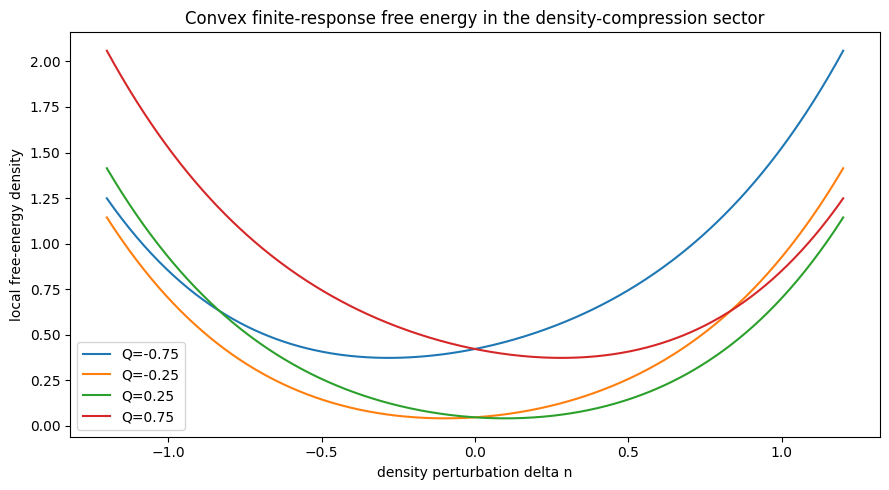

In [ ]:

dn = np.linspace(-1.2,1.2,500)
Q_values = [-0.75, -0.25, 0.25, 0.75]
plt.figure(figsize=(9,5))
for Q in Q_values:
    F = 0.5*a*dn**2 + 0.25*params['b']*dn**4 + 0.5*K*(Q-alpha*dn)**2
    plt.plot(dn,F,label=f'Q={Q}')
plt.xlabel('density perturbation delta n')
plt.ylabel('local free-energy density')
plt.title('Convex finite-response free energy in the density-compression sector')
plt.legend()
plt.tight_layout()
plt.savefig(FIG/'figure_02_scalar_free_energy.png',dpi=220)
plt.savefig(OUT/'ng1r_scalar_free_energy.png',dpi=180)
plt.show()



## 4. Linear mode spectrum

Let \(Q=\operatorname{tr}q\) be the compressional response. The phase-density and compression equations give two coupled branches.

Define

\[
A_n(k)=a+K\alpha^2+\kappa_nk^2,
\qquad
D_Q(k)=K+B_qk^2,
\qquad
\lambda=-K\alpha.
\]

The squared frequencies are the eigenvalues of

\[
\mathsf M(k)
=
\begin{pmatrix}
\rho_s k^2A_n(k) & \rho_s k^2\lambda\\
\lambda/A_q & D_Q(k)/A_q
\end{pmatrix}.
\]

Equivalently,

\[
\omega_\pm^2
=
\frac12
\left[
T\pm\sqrt{T^2-4\Delta}
\right],
\]

where

\[
T=\rho_sk^2A_n+\frac{D_Q}{A_q},
\qquad
\Delta=
\frac{\rho_sk^2}{A_q}
\left[A_nD_Q-\lambda^2\right].
\]

The low-\(k\) massless branch has

\[
c_{\rm scalar}^2
=
\rho_s
\left[
(a+K\alpha^2)-\frac{K^2\alpha^2}{K}
\right]
=
\rho_sa.
\]

Thus compression locking changes amplitudes and the gapped branch while preserving the low-frequency scalar speed selected by the underlying density stiffness.

Additional modes are

\[
\omega_T^2
=
\Omega_T^2+\frac{B_q}{A_q}k^2,
\]

\[
\omega_\chi^2
=
\frac{m_\chi^2}{A_\chi}
+
\frac{\kappa_\chi}{A_\chi}k^2,
\]

\[
\omega_z^2
=
\frac{\Omega_z^2}{A_z}
+
\frac{B_z}{A_z}k^2.
\]


In [ ]:

k = np.linspace(1e-4,1.0,700)
a_eff = params['a'] + params['K']*params['alpha']**2
lam = -params['K']*params['alpha']
An = a_eff + params['kappa_n']*k**2
Dq = params['K'] + params['B_q']*k**2
T = params['rho_s']*k**2*An + Dq/params['A_q']
Det = params['rho_s']*k**2*(An*Dq-lam**2)/params['A_q']
disc = np.maximum(T**2-4*Det,0)
omega_minus = np.sqrt((T-np.sqrt(disc))/2)
omega_plus = np.sqrt((T+np.sqrt(disc))/2)
omega_tensor = np.sqrt(2*params['G']/params['A_q'] + params['B_q']/params['A_q']*k**2)
omega_chi = np.sqrt(params['m_chi_sq']/params['A_chi'] + params['kappa_chi']/params['A_chi']*k**2)
omega_z = np.sqrt(params['Omega_z_sq']/params['A_z'] + params['B_z']/params['A_z']*k**2)

vg_minus = np.gradient(omega_minus,k)
vg_plus = np.gradient(omega_plus,k)
vg_tensor = np.gradient(omega_tensor,k)
vg_chi = np.gradient(omega_chi,k)
vg_z = np.gradient(omega_z,k)

mode_summary_df = pd.DataFrame([
    ('scalar massless',omega_minus[-1],vg_minus.max(),np.sqrt(params['rho_s']*params['a'])),
    ('scalar compression',omega_plus[0],vg_plus.max(),np.nan),
    ('traceless tensor response',omega_tensor[0],vg_tensor.max(),np.sqrt(params['B_q']/params['A_q'])),
    ('coherence',omega_chi[0],vg_chi.max(),np.sqrt(params['kappa_chi']/params['A_chi'])),
    ('internal orientation',omega_z[0],vg_z.max(),np.sqrt(params['B_z']/params['A_z'])),
], columns=['mode','reference_frequency','max_group_speed_k_le_1','asymptotic_or_low_k_speed'])
mode_summary_df.to_csv(OUT/'ng1r_mode_summary.csv', index=False)
display(mode_summary_df)

assert np.all((An*Dq-lam**2)>0)
assert np.all(omega_minus>=0)
assert np.all(omega_plus>0)
assert max(vg_minus.max(),vg_plus.max(),vg_tensor.max(),vg_chi.max(),vg_z.max()) <= 1.0+1e-6


,mode,reference_frequency,max_group_speed_k_le_1,asymptotic_or_low_k_speed
0,scalar massless,0.852980,0.931569,0.806226
1,scalar compression,1.224745,0.409641,NaN
2,traceless tensor response,1.183216,0.330667,0.670820
3,coherence,1.000000,0.445230,0.745356
4,internal orientation,1.172604,0.583078,0.935414


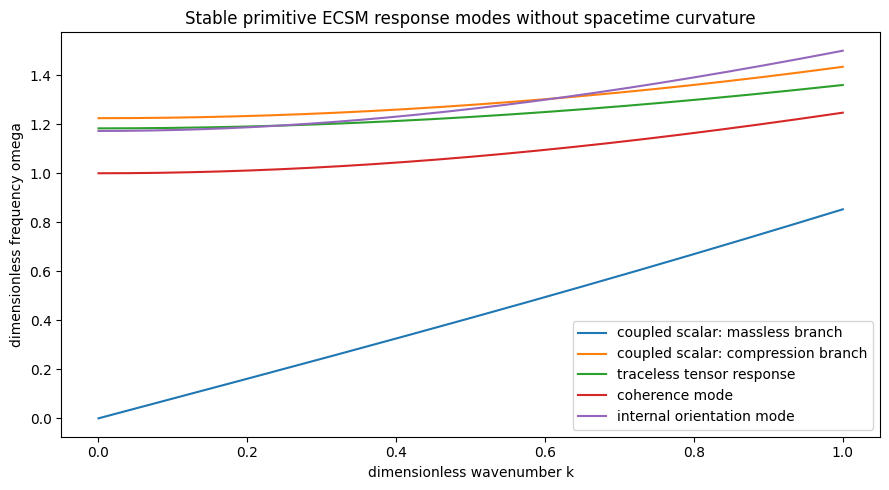

In [ ]:

plt.figure(figsize=(9,5))
plt.plot(k,omega_minus,label='coupled scalar: massless branch')
plt.plot(k,omega_plus,label='coupled scalar: compression branch')
plt.plot(k,omega_tensor,label='traceless tensor response')
plt.plot(k,omega_chi,label='coherence mode')
plt.plot(k,omega_z,label='internal orientation mode')
plt.xlabel('dimensionless wavenumber k')
plt.ylabel('dimensionless frequency omega')
plt.title('Stable primitive ECSM response modes without spacetime curvature')
plt.legend()
plt.tight_layout()
plt.savefig(FIG/'figure_03_mode_spectrum.png',dpi=220)
plt.savefig(OUT/'ng1r_mode_spectrum.png',dpi=180)
plt.show()



## 5. Localised-source response

A static source is used only as a loading probe. It is not inserted as a spacetime stress tensor.

For the coupled density-compression sector,

\[
\begin{pmatrix}
A_n(k) & \lambda\\
\lambda & D_Q(k)
\end{pmatrix}
\begin{pmatrix}
\delta n_k\\Q_k
\end{pmatrix}
=
\begin{pmatrix}
g_n\rho_{b,k}\\g_Q\rho_{b,k}
\end{pmatrix}.
\]

The resulting physical response gradient is represented by

\[
a_{\rm resp}(x)
=
-g_{\rm test}\,\partial_xQ(x).
\]

This is a finite constitutive-gradient response. It is not interpreted as curved geometry.


In [ ]:

N = 4096
L = 60.0
x = np.linspace(-L/2,L/2,N,endpoint=False)
dx = L/N
kx = 2*np.pi*np.fft.fftfreq(N,d=dx)

sigma_src = 1.5
rho_b = np.exp(-0.5*(x/sigma_src)**2)
rho_b /= np.trapz(rho_b,x)
rho_k = np.fft.fft(rho_b)

Ak = a_eff + params['kappa_n']*kx**2
Dk = params['K'] + params['B_q']*kx**2
detk = Ak*Dk-lam**2

g_n = 1.0
g_q = 0.20
n_k = (g_n*Dk-lam*g_q)*rho_k/detk
q_k = (g_q*Ak-lam*g_n)*rho_k/detk

dn_x = np.fft.ifft(n_k).real
Q_x = np.fft.ifft(q_k).real
a_resp = -np.fft.ifft(1j*kx*q_k).real

source_df = pd.DataFrame({
    'x':x,
    'source_density':rho_b,
    'density_response':dn_x,
    'compression_response':Q_x,
    'response_acceleration':a_resp
})
source_df.to_csv(OUT/'ng1r_localised_source_response.csv',index=False)

source_summary_df = pd.DataFrame([{
    'source_integral':np.trapz(rho_b,x),
    'max_abs_density_response':np.max(np.abs(dn_x)),
    'max_abs_compression_response':np.max(np.abs(Q_x)),
    'max_abs_response_acceleration':np.max(np.abs(a_resp)),
    'net_response_acceleration':np.trapz(a_resp,x),
    'all_values_finite':bool(np.isfinite(source_df.select_dtypes(float)).all().all())
}])
source_summary_df.to_csv(OUT/'ng1r_source_response_summary.csv',index=False)
display(source_summary_df)

assert np.isclose(np.trapz(rho_b,x),1,rtol=2e-4)
assert np.isfinite(source_df.select_dtypes(float)).all().all()
assert abs(np.trapz(a_resp,x))<1e-10


/tmp/ipykernel_10130/1144584433.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rho_b /= np.trapz(rho_b,x)
/tmp/ipykernel_10130/1144584433.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  'source_integral':np.trapz(rho_b,x),
/tmp/ipykernel_10130/1144584433.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  'net_response_acceleration':np.trapz(a_resp,x),


,source_integral,max_abs_density_response,max_abs_compression_response,max_abs_response_acceleration,net_response_acceleration,all_values_finite
0,1.0,0.261856,0.103454,0.036119,0.0,True


/tmp/ipykernel_10130/1144584433.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  assert np.isclose(np.trapz(rho_b,x),1,rtol=2e-4)
/tmp/ipykernel_10130/1144584433.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  assert abs(np.trapz(a_resp,x))<1e-10


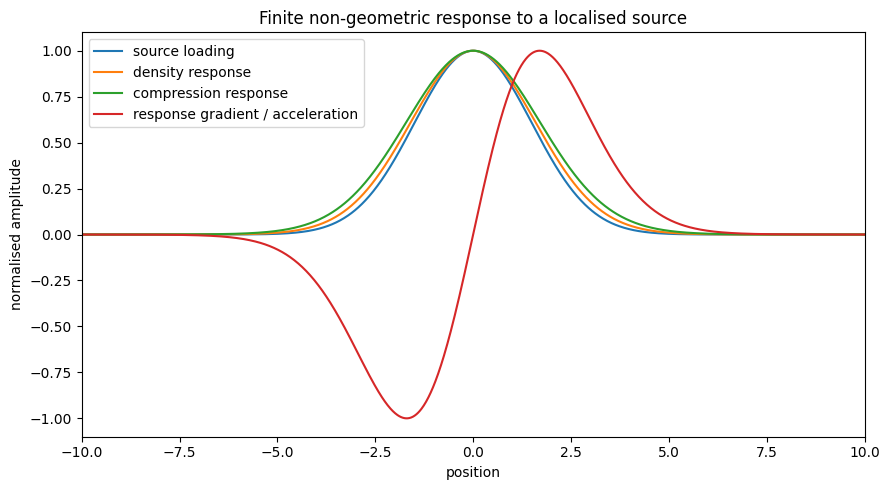

In [ ]:

norm = lambda y: y/np.max(np.abs(y)) if np.max(np.abs(y))>0 else y
plt.figure(figsize=(9,5))
plt.plot(x,norm(rho_b),label='source loading')
plt.plot(x,norm(dn_x),label='density response')
plt.plot(x,norm(Q_x),label='compression response')
plt.plot(x,norm(a_resp),label='response gradient / acceleration')
plt.xlim(-10,10)
plt.xlabel('position')
plt.ylabel('normalised amplitude')
plt.title('Finite non-geometric response to a localised source')
plt.legend()
plt.tight_layout()
plt.savefig(FIG/'figure_05_localised_source_response.png',dpi=220)
plt.savefig(OUT/'ng1r_localised_source_response.png',dpi=180)
plt.show()



## 6. Random stability and finite-speed audit

The scan tests a broad positive parameter region without importing any gravitational or Planck-scale coefficient.

A sampled point is accepted when:

1. the local scalar Hessian is positive;
2. the scalar low-\(k\) speed is finite and no greater than the reference response speed;
3. the tensor, coherence, and orientation characteristic speeds do not exceed the reference speed;
4. both coupled scalar branches have positive \(\omega^2\) over \(0<k\leq1\);
5. the scalar group speeds remain finite and sub-reference over the stated effective cutoff.

This proves existence of a nonempty stable region. It does not determine nature's parameters.


In [ ]:

Nscan = 50000
scan = pd.DataFrame({
    'a':rng.uniform(0.2,1.5,Nscan),
    'K':rng.uniform(0.3,2.5,Nscan),
    'alpha':rng.uniform(0.0,0.65,Nscan),
    'kappa_n':rng.uniform(0.02,0.20,Nscan),
    'rho_s':rng.uniform(0.2,0.8,Nscan),
    'A_q':rng.uniform(0.7,1.5,Nscan),
    'B_q':rng.uniform(0.1,0.8,Nscan),
    'A_chi':rng.uniform(0.7,1.5,Nscan),
    'kappa_chi':rng.uniform(0.1,0.9,Nscan),
    'A_z':rng.uniform(0.7,1.5,Nscan),
    'B_z':rng.uniform(0.1,1.2,Nscan),
})

scan['hessian_det'] = scan.a*scan.K
scan['c_scalar_sq'] = scan.rho_s*scan.a
scan['c_tensor_sq'] = scan.B_q/scan.A_q
scan['c_chi_sq'] = scan.kappa_chi/scan.A_chi
scan['c_z_sq'] = scan.B_z/scan.A_z

scan['positive_hessian'] = scan.hessian_det>0
scan['scalar_speed_ok'] = (scan.c_scalar_sq>0)&(scan.c_scalar_sq<=1)
scan['tensor_speed_ok'] = (scan.c_tensor_sq>0)&(scan.c_tensor_sq<=1)
scan['chi_speed_ok'] = (scan.c_chi_sq>0)&(scan.c_chi_sq<=1)
scan['orientation_speed_ok'] = (scan.c_z_sq>0)&(scan.c_z_sq<=1)

kgrid = np.linspace(0.02,1.0,50)
wm = np.empty((Nscan,len(kgrid)))
wp = np.empty((Nscan,len(kgrid)))
positive_branches = np.ones(Nscan,dtype=bool)

for j,kv in enumerate(kgrid):
    ae = scan.a.values + scan.K.values*scan.alpha.values**2
    la = -scan.K.values*scan.alpha.values
    Akn = ae + scan.kappa_n.values*kv**2
    Dkn = scan.K.values + scan.B_q.values*kv**2
    tr = scan.rho_s.values*kv**2*Akn + Dkn/scan.A_q.values
    de = scan.rho_s.values*kv**2*(Akn*Dkn-la**2)/scan.A_q.values
    di = tr**2-4*de
    positive_branches &= (de>0)&(di>=-1e-12)
    di = np.maximum(di,0)
    wm[:,j] = np.sqrt(np.maximum((tr-np.sqrt(di))/2,0))
    wp[:,j] = np.sqrt(np.maximum((tr+np.sqrt(di))/2,0))

vgm = np.gradient(wm,kgrid,axis=1)
vgp = np.gradient(wp,kgrid,axis=1)
scan['positive_scalar_branches'] = positive_branches
scan['max_scalar_group_speed'] = np.maximum(np.max(vgm,axis=1),np.max(vgp,axis=1))
scan['scalar_group_speed_ok'] = np.isfinite(scan.max_scalar_group_speed)&(scan.max_scalar_group_speed<=1)

condition_cols = [
    'positive_hessian','scalar_speed_ok','tensor_speed_ok','chi_speed_ok',
    'orientation_speed_ok','positive_scalar_branches','scalar_group_speed_ok'
]
scan['all_conditions'] = scan[condition_cols].all(axis=1)

scan.to_csv(OUT/'ng1r_random_stability_scan_50000.csv',index=False)

audit_summary = pd.DataFrame({
    'condition':condition_cols+['all_conditions'],
    'passed':[int(scan[c].sum()) for c in condition_cols+['all_conditions']],
})
audit_summary['total']=Nscan
audit_summary['fraction']=audit_summary.passed/audit_summary.total
audit_summary.to_csv(OUT/'ng1r_random_stability_audit_summary.csv',index=False)
display(audit_summary)

assert scan.all_conditions.sum()>10000
assert scan.positive_scalar_branches.all()


,condition,passed,total,fraction
0,positive_hessian,50000,50000,1.00000
1,scalar_speed_ok,48938,50000,0.97876
2,tensor_speed_ok,49569,50000,0.99138
3,chi_speed_ok,48469,50000,0.96938
4,orientation_speed_ok,42842,50000,0.85684
5,positive_scalar_branches,50000,50000,1.00000
6,scalar_group_speed_ok,47116,50000,0.94232
7,all_conditions,38900,50000,0.77800


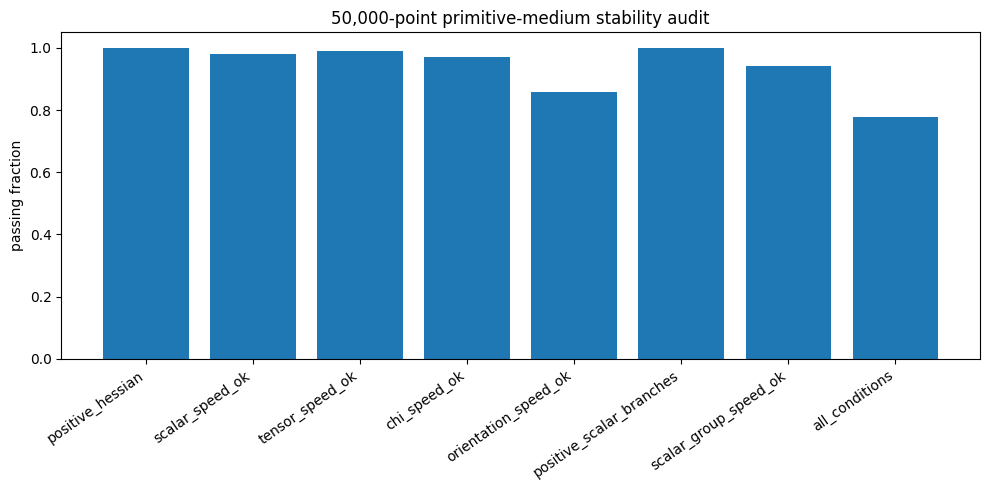

In [ ]:

plt.figure(figsize=(10,5))
plt.bar(audit_summary.condition,audit_summary.fraction)
plt.ylim(0,1.05)
plt.xticks(rotation=35,ha='right')
plt.ylabel('passing fraction')
plt.title('50,000-point primitive-medium stability audit')
plt.tight_layout()
plt.savefig(FIG/'figure_04_random_stability_audit.png',dpi=220)
plt.savefig(OUT/'ng1r_random_stability_audit.png',dpi=180)
plt.show()



## 7. Architecture and replacement map

The old geometric gravity spine is replaced at the primitive level:

| Removed primitive | NG1R replacement |
|---|---|
| physical \(g_{\mu\nu}\) | constitutive spatial response \(q_{ij}\) |
| \(\sqrt{-g}R\) | convex local and gradient free energy |
| Einstein equation | variational medium response equations |
| null cone as spacetime geometry | characteristic dispersion from the principal response operator |
| metric perturbation | tensorial stress/orientation mode |
| curvature source | density, stress, coherence, and boundary gradients |
| event horizon | transport threshold |


In [ ]:

replacement_df = pd.DataFrame([
    ('physical spacetime metric g_mu_nu','constitutive spatial response q_ij','primitive variable'),
    ('Einstein-Hilbert density sqrt(-g) R','convex local and gradient free energy','primitive dynamics'),
    ('Einstein tensor equation','variational constitutive response equations','field equations'),
    ('spacetime null cone','characteristic dispersion of the principal response operator','propagation'),
    ('metric perturbation','tensorial stress / orientation perturbation','wave sector'),
    ('curvature source','density, stress, coherence, and boundary gradients','source mechanism'),
    ('metric event horizon','transport threshold |u_n|=c_eff','strong-field interpretation'),
    ('Schwarzschild or Kerr ontology','external observational comparison template','comparison only'),
], columns=['removed_structure','non_geometric_replacement','role'])
replacement_df.to_csv(OUT/'ng1r_geometric_to_non_geometric_replacement_map.csv',index=False)
display(replacement_df)


,removed_structure,non_geometric_replacement,role
0,physical spacetime metric g_mu_nu,constitutive spatial response q_ij,primitive variable
1,Einstein-Hilbert density sqrt(-g) R,convex local and gradient free energy,primitive dynamics
2,Einstein tensor equation,variational constitutive response equations,field equations
3,spacetime null cone,characteristic dispersion of the principal res...,propagation
4,metric perturbation,tensorial stress / orientation perturbation,wave sector
5,curvature source,"density, stress, coherence, and boundary gradi...",source mechanism
6,metric event horizon,transport threshold |u_n|=c_eff,strong-field interpretation
7,Schwarzschild or Kerr ontology,external observational comparison template,comparison only


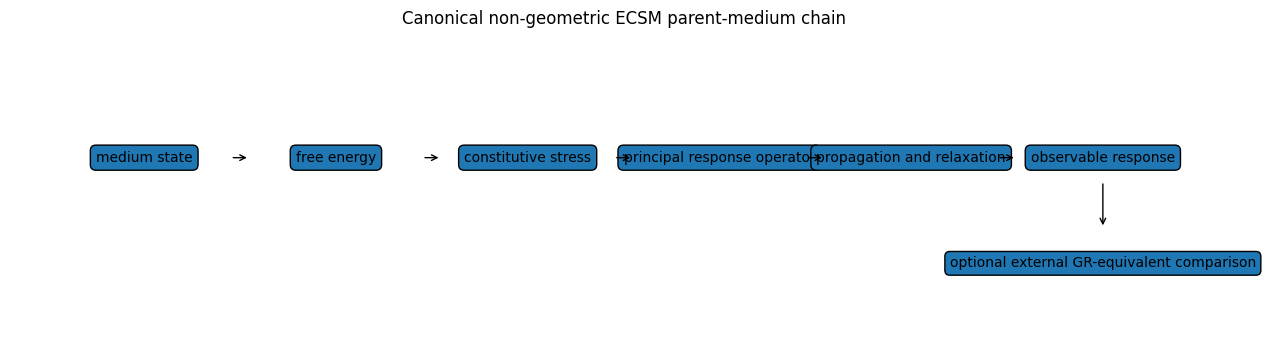

In [ ]:

# Architecture figure with no physical metric stage.
nodes = [
    ('medium state',0,0),
    ('free energy',1,0),
    ('constitutive stress',2,0),
    ('principal response operator',3,0),
    ('propagation and relaxation',4,0),
    ('observable response',5,0),
]
plt.figure(figsize=(13,3.5))
ax = plt.gca()
for label,xp,yp in nodes:
    ax.text(xp,yp,label,ha='center',va='center',bbox=dict(boxstyle='round,pad=0.4'))
for i in range(len(nodes)-1):
    ax.annotate('',xy=(nodes[i+1][1]-0.45,0),xytext=(nodes[i][1]+0.45,0),
                arrowprops=dict(arrowstyle='->'))
ax.text(5,-0.7,'optional external GR-equivalent comparison',ha='center',
        bbox=dict(boxstyle='round,pad=0.35'))
ax.annotate('',xy=(5,-0.45),xytext=(5,-0.15),arrowprops=dict(arrowstyle='->'))
ax.set_xlim(-0.7,5.7)
ax.set_ylim(-1.1,0.8)
ax.axis('off')
ax.set_title('Canonical non-geometric ECSM parent-medium chain')
plt.tight_layout()
plt.savefig(FIG/'figure_01_non_geometric_architecture.png',dpi=220)
plt.savefig(OUT/'ng1r_non_geometric_architecture.png',dpi=180)
plt.show()



## 8. Ontology audit

The primitive action and parent equations are scanned for prohibited geometric structures.

The scan applies to the physical equation set, not to historical comparison text.


In [ ]:

primitive_equation_text = '''
S_med = integral d_lambda d3x [
n theta_dot
+ A_q q_dot_ij q_dot_ij / 2
+ A_chi chi_dot^2 / 2
+ A_z |D_lambda z|^2
- epsilon(n,chi)
- kappa_n |grad n|^2 / 2
- rho_s |grad theta|^2 / 2
- kappa_chi |grad chi|^2 / 2
- B_q |grad q_ij|^2 / 2
- K [tr(q)-alpha(n-n0)]^2 / 2
- G q_dev:q_dev
- B_z |D_i z|^2
- V_z
+ sources
]
n_dot = rho_s Laplacian(theta)
A_q q_ddot_ij - B_q Laplacian(q_ij) + Sigma_ij = J_ij
A_chi chi_ddot - kappa_chi Laplacian(chi) + epsilon_chi + Vz_chi = J_chi
'''

forbidden = [
    'sqrt(-g)','Ricci','Einstein tensor','G_mu_nu','R[g',
    'geodesic','Schwarzschild','Kerr','FLRW','TOV',
    'curvature invariant','event horizon'
]
ontology_rows = []
for token in forbidden:
    count = primitive_equation_text.lower().count(token.lower())
    ontology_rows.append((token,count,count==0))

ontology_audit_df = pd.DataFrame(ontology_rows,columns=['prohibited_structure','occurrences_in_primitive_equations','passed'])
ontology_audit_df.to_csv(OUT/'ng1r_ontology_audit.csv',index=False)
display(ontology_audit_df)

assert ontology_audit_df.passed.all()


,prohibited_structure,occurrences_in_primitive_equations,passed
0,sqrt(-g),0,True
1,Ricci,0,True
2,Einstein tensor,0,True
3,G_mu_nu,0,True
4,R[g,0,True
5,geodesic,0,True
6,Schwarzschild,0,True
7,Kerr,0,True
8,FLRW,0,True
9,TOV,0,True



## 9. Claim ledger

### Derived in NG1R

- constitutive stress from the free energy;
- the parent variational equations;
- local convexity of the benchmark scalar response;
- the coupled scalar dispersion relation;
- stable tensor, coherence, and orientation modes;
- a finite localised-source response;
- a nonempty stable and finite-speed parameter region.

### Conditional

- the specific primitive action;
- isotropy of the benchmark constitutive coefficients;
- the selected polynomial equation of state;
- the interpretation of \(q_{ij}\) as the parent response tensor;
- the source couplings used in the demonstration.

### Not yet derived

- the numerical value of Newton's constant;
- inverse-square gravity in three dimensions;
- exact Solar-System and binary observables;
- clock-rate shifts;
- lensing and Shapiro-like delay;
- gravitational-wave amplitudes and emission;
- rotation and frame-dragging-equivalent response;
- compact-object tidal response;
- CMB and cosmological transfer.


In [ ]:

claim_df = pd.DataFrame([
    ('primitive non-geometric parent action exists','conditional construction','established as a sufficient model, not unique'),
    ('constitutive stress follows from free energy','derived','exact within the stated action'),
    ('scalar Hessian is positive for a>0 and K>0','derived','analytic determinant aK'),
    ('stable coupled scalar modes exist','derived and numerically verified','benchmark and random scan'),
    ('tensor/coherence/orientation modes are finite','derived and numerically verified','benchmark'),
    ('localized sources create finite response gradients','numerically verified','one-dimensional loading test'),
    ('physical spacetime curvature is required','rejected','not present in primitive equations'),
    ('Newton constant is derived','not derived','reserved for NG2'),
    ('PPN and light deflection are derived','not derived','reserved for NG3-NG5'),
    ('compact-object predictions are derived','not derived','reserved for NG7'),
], columns=['claim','status','boundary'])
claim_df.to_csv(OUT/'ng1r_claim_ledger.csv',index=False)
display(claim_df)


,claim,status,boundary
0,primitive non-geometric parent action exists,conditional construction,"established as a sufficient model, not unique"
1,constitutive stress follows from free energy,derived,exact within the stated action
2,scalar Hessian is positive for a>0 and K>0,derived,analytic determinant aK
3,stable coupled scalar modes exist,derived and numerically verified,benchmark and random scan
4,tensor/coherence/orientation modes are finite,derived and numerically verified,benchmark
5,localized sources create finite response gradi...,numerically verified,one-dimensional loading test
6,physical spacetime curvature is required,rejected,not present in primitive equations
7,Newton constant is derived,not derived,reserved for NG2
8,PPN and light deflection are derived,not derived,reserved for NG3-NG5
9,compact-object predictions are derived,not derived,reserved for NG7



## 10. Paper-ready interpretation

NG1R restores the primitive theory to the intended ECSM ontology.

The tensor \(q_{ij}\) is a physical constitutive response field. It stores compression and shear, couples to density, supports finite tensorial modes, and contributes to source-driven gradients. It is not exponentiated into a spacetime metric.

The characteristic structure follows from the principal response operator. A common propagation speed, if recovered in later notebooks, will be a constitutive symmetry of the medium. It will not imply that waves inhabit a physically curved spacetime.

The optional GR comparison layer is downstream of the physical calculation and is not part of the primitive action.


In [ ]:

paper_summary = {
    'notebook':'ECSM NG1R',
    'title':'Primitive Non-Geometric Parent Medium and Constitutive Response Closure',
    'primitive_variables':['n','theta','chi','q_ij','z','X_A'],
    'physical_metric':False,
    'curvature_action':False,
    'einstein_equations':False,
    'stable_benchmark':True,
    'random_points':Nscan,
    'random_points_passing_all_conditions':int(scan.all_conditions.sum()),
    'random_passing_fraction':float(scan.all_conditions.mean()),
    'paper_figures':len(list(FIG.glob('figure_*.png'))),
    'main_result':'A stable, finite, source-responsive parent-medium action exists without physical spacetime curvature.',
    'next_notebook':'NG2R - Inertia and Static Gravitational Response from One Matter-Medium Coupling'
}
(OUT/'ng1r_metadata.json').write_text(json.dumps(paper_summary,indent=2))
print(json.dumps(paper_summary,indent=2))


{
  "notebook": "ECSM NG1R",
  "title": "Primitive Non-Geometric Parent Medium and Constitutive Response Closure",
  "primitive_variables": [
    "n",
    "theta",
    "chi",
    "q_ij",
    "z",
    "X_A"
  ],
  "physical_metric": false,
  "curvature_action": false,
  "einstein_equations": false,
  "stable_benchmark": true,
  "random_points": 50000,
  "random_points_passing_all_conditions": 38900,
  "random_passing_fraction": 0.778,
  "paper_figures": 5,
  "main_result": "A stable, finite, source-responsive parent-medium action exists without physical spacetime curvature.",
  "next_notebook": "NG2R - Inertia and Static Gravitational Response from One Matter-Medium Coupling"
}



## 11. Final verification


In [ ]:

tests = []
def rec(name,passed,detail=''):
    tests.append({'test':name,'passed':bool(passed),'detail':str(detail)})

rec('Primitive variable table exported',(OUT/'ng1r_primitive_variables.csv').exists())
rec('Action term table exported',(OUT/'ng1r_action_terms.csv').exists())
rec('Parent equation table exported',(OUT/'ng1r_parent_equations.csv').exists())
rec('Benchmark parameter table exported',(OUT/'ng1r_benchmark_parameters.csv').exists())
rec('Scalar Hessian symmetric',np.allclose(H,H.T))
rec('Scalar Hessian positive',np.all(evals>0))
rec('Scalar Hessian determinant equals aK',np.isclose(np.linalg.det(H),a*K))
rec('Compression coefficient positive',params['K']>0)
rec('Shear coefficient positive',params['G']>0)
rec('Density-gradient coefficient positive',params['kappa_n']>0)
rec('Coherence-gradient coefficient positive',params['kappa_chi']>0)
rec('Orientation-gradient coefficient positive',params['B_z']>0)
rec('Coupled scalar determinant positive for all benchmark k',np.all((An*Dq-lam**2)>0))
rec('Massless scalar branch nonnegative',np.all(omega_minus>=0))
rec('Compression branch positive',np.all(omega_plus>0))
rec('Tensor mode positive',np.all(omega_tensor>0))
rec('Coherence mode positive',np.all(omega_chi>0))
rec('Orientation mode positive',np.all(omega_z>0))
rec('Low-k scalar speed equals sqrt(rho_s a)',np.isclose(np.sqrt(params['rho_s']*params['a']),mode_summary_df.iloc[0].asymptotic_or_low_k_speed))
rec('Benchmark scalar group speed finite',np.isfinite(vg_minus).all() and np.isfinite(vg_plus).all())
rec('Benchmark scalar group speeds sub-reference',max(vg_minus.max(),vg_plus.max())<=1+1e-6)
rec('Benchmark tensor group speed sub-reference',vg_tensor.max()<=1+1e-6)
rec('Benchmark coherence group speed sub-reference',vg_chi.max()<=1+1e-6)
rec('Benchmark orientation group speed sub-reference',vg_z.max()<=1+1e-6)
rec('Source integral normalised',np.isclose(np.trapz(rho_b,x),1,rtol=2e-4))
rec('Source response finite',np.isfinite(source_df.select_dtypes(float)).all().all())
rec('Source compression response nonzero',np.max(np.abs(Q_x))>0)
rec('Source density response nonzero',np.max(np.abs(dn_x))>0)
rec('Response acceleration nonzero',np.max(np.abs(a_resp))>0)
rec('Symmetric source has zero net acceleration',abs(np.trapz(a_resp,x))<1e-10)
rec('Random audit contains 50,000 points',len(scan)==50000)
rec('All random points have positive scalar branches',scan.positive_scalar_branches.all())
rec('Random audit has more than 10,000 fully viable points',scan.all_conditions.sum()>10000)
rec('Random scan export exists',(OUT/'ng1r_random_stability_scan_50000.csv').exists())
rec('Replacement map exported',(OUT/'ng1r_geometric_to_non_geometric_replacement_map.csv').exists())
rec('Ontology audit exported',(OUT/'ng1r_ontology_audit.csv').exists())
rec('No prohibited structure appears in primitive equations',ontology_audit_df.passed.all())
rec('Claim ledger exported',(OUT/'ng1r_claim_ledger.csv').exists())
rec('Metadata exported',(OUT/'ng1r_metadata.json').exists())
rec('Five paper figures exported',len(list(FIG.glob('figure_*.png')))==5)
rec('No physical metric in metadata',paper_summary['physical_metric'] is False)
rec('No curvature action in metadata',paper_summary['curvature_action'] is False)
rec('No Einstein equations in metadata',paper_summary['einstein_equations'] is False)

test_df = pd.DataFrame(tests)
test_df.to_csv(OUT/'ng1r_test_summary.csv',index=False)
display(test_df)
print(f"Passed {test_df.passed.sum()}/{len(test_df)} NG1R tests")
assert test_df.passed.all()


/tmp/ipykernel_10130/3189634048.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rec('Source integral normalised',np.isclose(np.trapz(rho_b,x),1,rtol=2e-4))
/tmp/ipykernel_10130/3189634048.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rec('Symmetric source has zero net acceleration',abs(np.trapz(a_resp,x))<1e-10)


,test,passed,detail
0,Primitive variable table exported,True,
1,Action term table exported,True,
2,Parent equation table exported,True,
3,Benchmark parameter table exported,True,
4,Scalar Hessian symmetric,True,
5,Scalar Hessian positive,True,
6,Scalar Hessian determinant equals aK,True,
7,Compression coefficient positive,True,
8,Shear coefficient positive,True,
9,Density-gradient coefficient positive,True,


Passed 43/43 NG1R tests


In [ ]:

figure_manifest = pd.DataFrame([
    {'filename':p.name,'size_kB':p.stat().st_size/1000}
    for p in sorted(FIG.glob('figure_*.png'))
])
figure_manifest.to_csv(OUT/'ng1r_paper_figure_manifest.csv',index=False)
display(figure_manifest)

equation_text = r'''# ECSM NG1R equations

Primitive action:
S_med = integral d_lambda d3x [
n theta_dot
+ A_q q_dot_ij q_dot_ij / 2
+ A_chi chi_dot^2 / 2
+ A_z |D_lambda z|^2
- F
+ J
]

Constitutive free energy:
F =
epsilon(n,chi)
+ kappa_n |grad n|^2 / 2
+ rho_s |grad theta|^2 / 2
+ kappa_chi |grad chi|^2 / 2
+ B_q |grad q_ij|^2 / 2
+ K [tr(q)-alpha(n-n0)]^2 / 2
+ G q_dev:q_dev
+ B_z |D_i z|^2
+ V_z

Stress:
Sigma_ij =
K [tr(q)-alpha(n-n0)] delta_ij
+ 2 G qdev_ij

No physical spacetime metric or curvature term is present.
'''
(OUT/'ng1r_equations.md').write_text(equation_text)


,filename,size_kB
0,figure_01_non_geometric_architecture.png,73.957
1,figure_02_scalar_free_energy.png,190.159
2,figure_03_mode_spectrum.png,146.205
3,figure_04_random_stability_audit.png,139.290
4,figure_05_localised_source_response.png,172.756


510


## 12. NG1R result

\[
\boxed{
S_{\rm ECSM}^{\rm primitive}
=
S_{\rm medium}
[n,\theta,\chi,q_{ij},z,X_A]
}
\]

with

\[
\boxed{
\text{no physical }g_{\mu\nu},
\quad
\text{no }R,
\quad
\text{no }G_{\mu\nu}.
}
\]

The primitive model possesses:

\[
\boxed{
\text{positive constitutive energy}
}
\]

\[
\boxed{
\text{stable scalar, tensorial, coherence, and orientation modes}
}
\]

\[
\boxed{
\text{finite source-driven response gradients}
}
\]

and a nonempty finite-speed stability region.

The first replacement foundation is therefore complete.

The next notebook is:

\[
\boxed{
\text{NG2R — Inertia and Static Gravitational Response from One Matter–Medium Coupling}.
}
\]
